# Plot SSS, SST, MLD, SIC for ice day in mackenzie point

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:44697")
client

<Client: 'tcp://127.0.0.1:44697' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

In [7]:
# remove 2021 since we only have January and a few days in Feb that year
salt_day = SALT_zarr_day.SALT.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
theta_day = THETA_zarr_day.THETA.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
ice_day = SI_zarr_day.SIarea.sel(time=slice("2014","2020")).where(HH_grid.mask_basin.isel(k=0)==1)*100 # convert to percentage

In [8]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

### Calculate potential density

In [9]:
# Convert depth (m) to pressure (dbar)
p = gsw.p_from_z(HH_grid.Z, 70)  # Depth is negative

# Convert Practical Salinity (SP) to Absolute Salinity (SA)
SA = gsw.SA_from_SP(salt_day, p, salt_day.XC, salt_day.YC)  # Assume longitude = 0 if unknown

# Convert Potential Temperature to Conservative Temperature
CT = gsw.conversions.CT_from_pt(SA, theta_day)

# Calculate potential density anomaly referenced to 0 dbar (1000 is subtracted)
sigma0 = gsw.sigma0(SA, CT)

In [10]:
sigma0.name = 'potential_density'
sigma0.attrs['long_name'] = 'potential_density'

### Plot sic time series

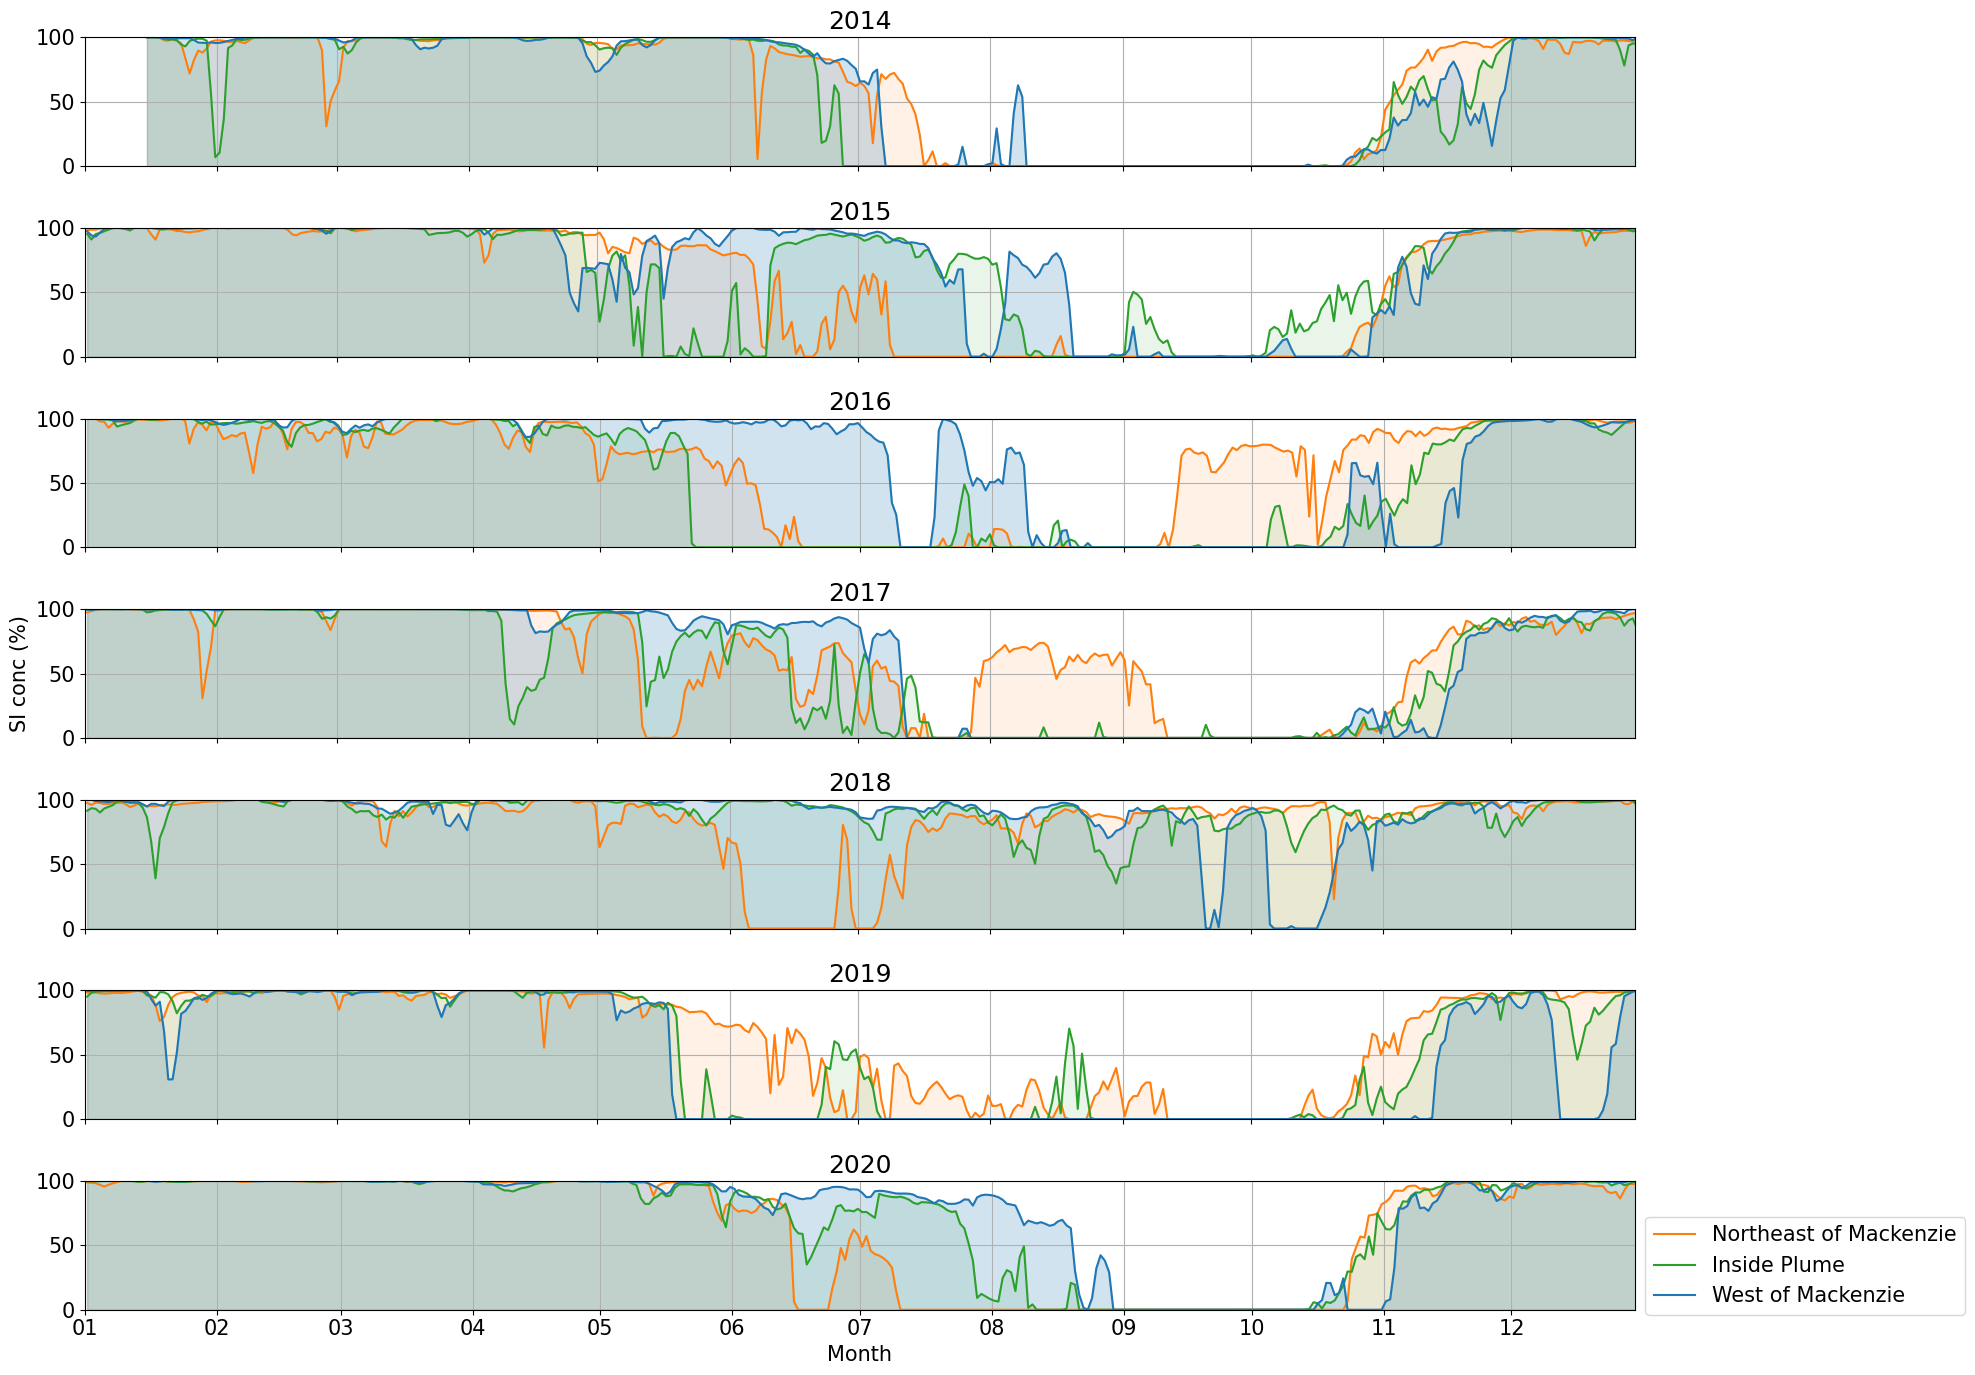

In [19]:
plt.rcParams['font.size'] = 15

years = np.arange(2014, 2021)  # 2014 to 2020

fig, axes = plt.subplots(nrows=len(years), figsize=(20, 14))

for i, year in enumerate(years):
    ax = axes[i]
    
    # Select data for the given year
    start_date = f"{year}-01-01"
    end_date = f"{year}-12-30"

    ice_grid_west_timeseries = ice_day.isel(i=i_west, j=j_west).sel(time=slice(start_date, end_date)).chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")
    ice_grid_plume_timeseries = ice_day.isel(i=i_plume, j=j_plume).sel(time=slice(start_date, end_date)).chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")
    ice_grid_east_timeseries = ice_day.isel(i=i_east, j=j_east).sel(time=slice(start_date, end_date)).chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")

    # Plot each region's time series with shading
    ax.plot(ice_grid_east_timeseries.time, ice_grid_east_timeseries, label="Northeast of Mackenzie", color='tab:orange')
    ax.fill_between(ice_grid_east_timeseries.time, ice_grid_east_timeseries, 0, alpha=0.1, color='tab:orange')

    ax.plot(ice_grid_plume_timeseries.time, ice_grid_plume_timeseries, label="Inside Plume", color='tab:green')
    ax.fill_between(ice_grid_plume_timeseries.time, ice_grid_plume_timeseries, 0, alpha=0.1, color='tab:green')

    ax.plot(ice_grid_west_timeseries.time, ice_grid_west_timeseries, label="West of Mackenzie", color='tab:blue')
    ax.fill_between(ice_grid_west_timeseries.time, ice_grid_west_timeseries, 0, alpha=0.2, color='tab:blue')

    ax.grid()
    ax.set_ylim(0, 100)
    ax.set_xlim([np.datetime64(start_date), np.datetime64(end_date)])

    # Remove tick labels except for the last (bottom) subplot
    if i < len(years) - 1:
        ax.set_xticklabels([])  # Hide tick labels for all but last subplot

    ax.set_ylabel("SI conc (%)" if i == len(years) // 2 else "")  # Only middle subplot gets a label

    # Title for each subplot
    ax.set_title(f"{year}")

# Format the x-axis of the last subplot
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks at the start of each month
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m"))  # Label ticks with month number (1-12)

# Add legend only to the last subplot
axes[-1].legend(loc='upper left', fontsize=15, bbox_to_anchor=[1, 0.8])

plt.xlabel("Month")
plt.tight_layout()
plt.show()

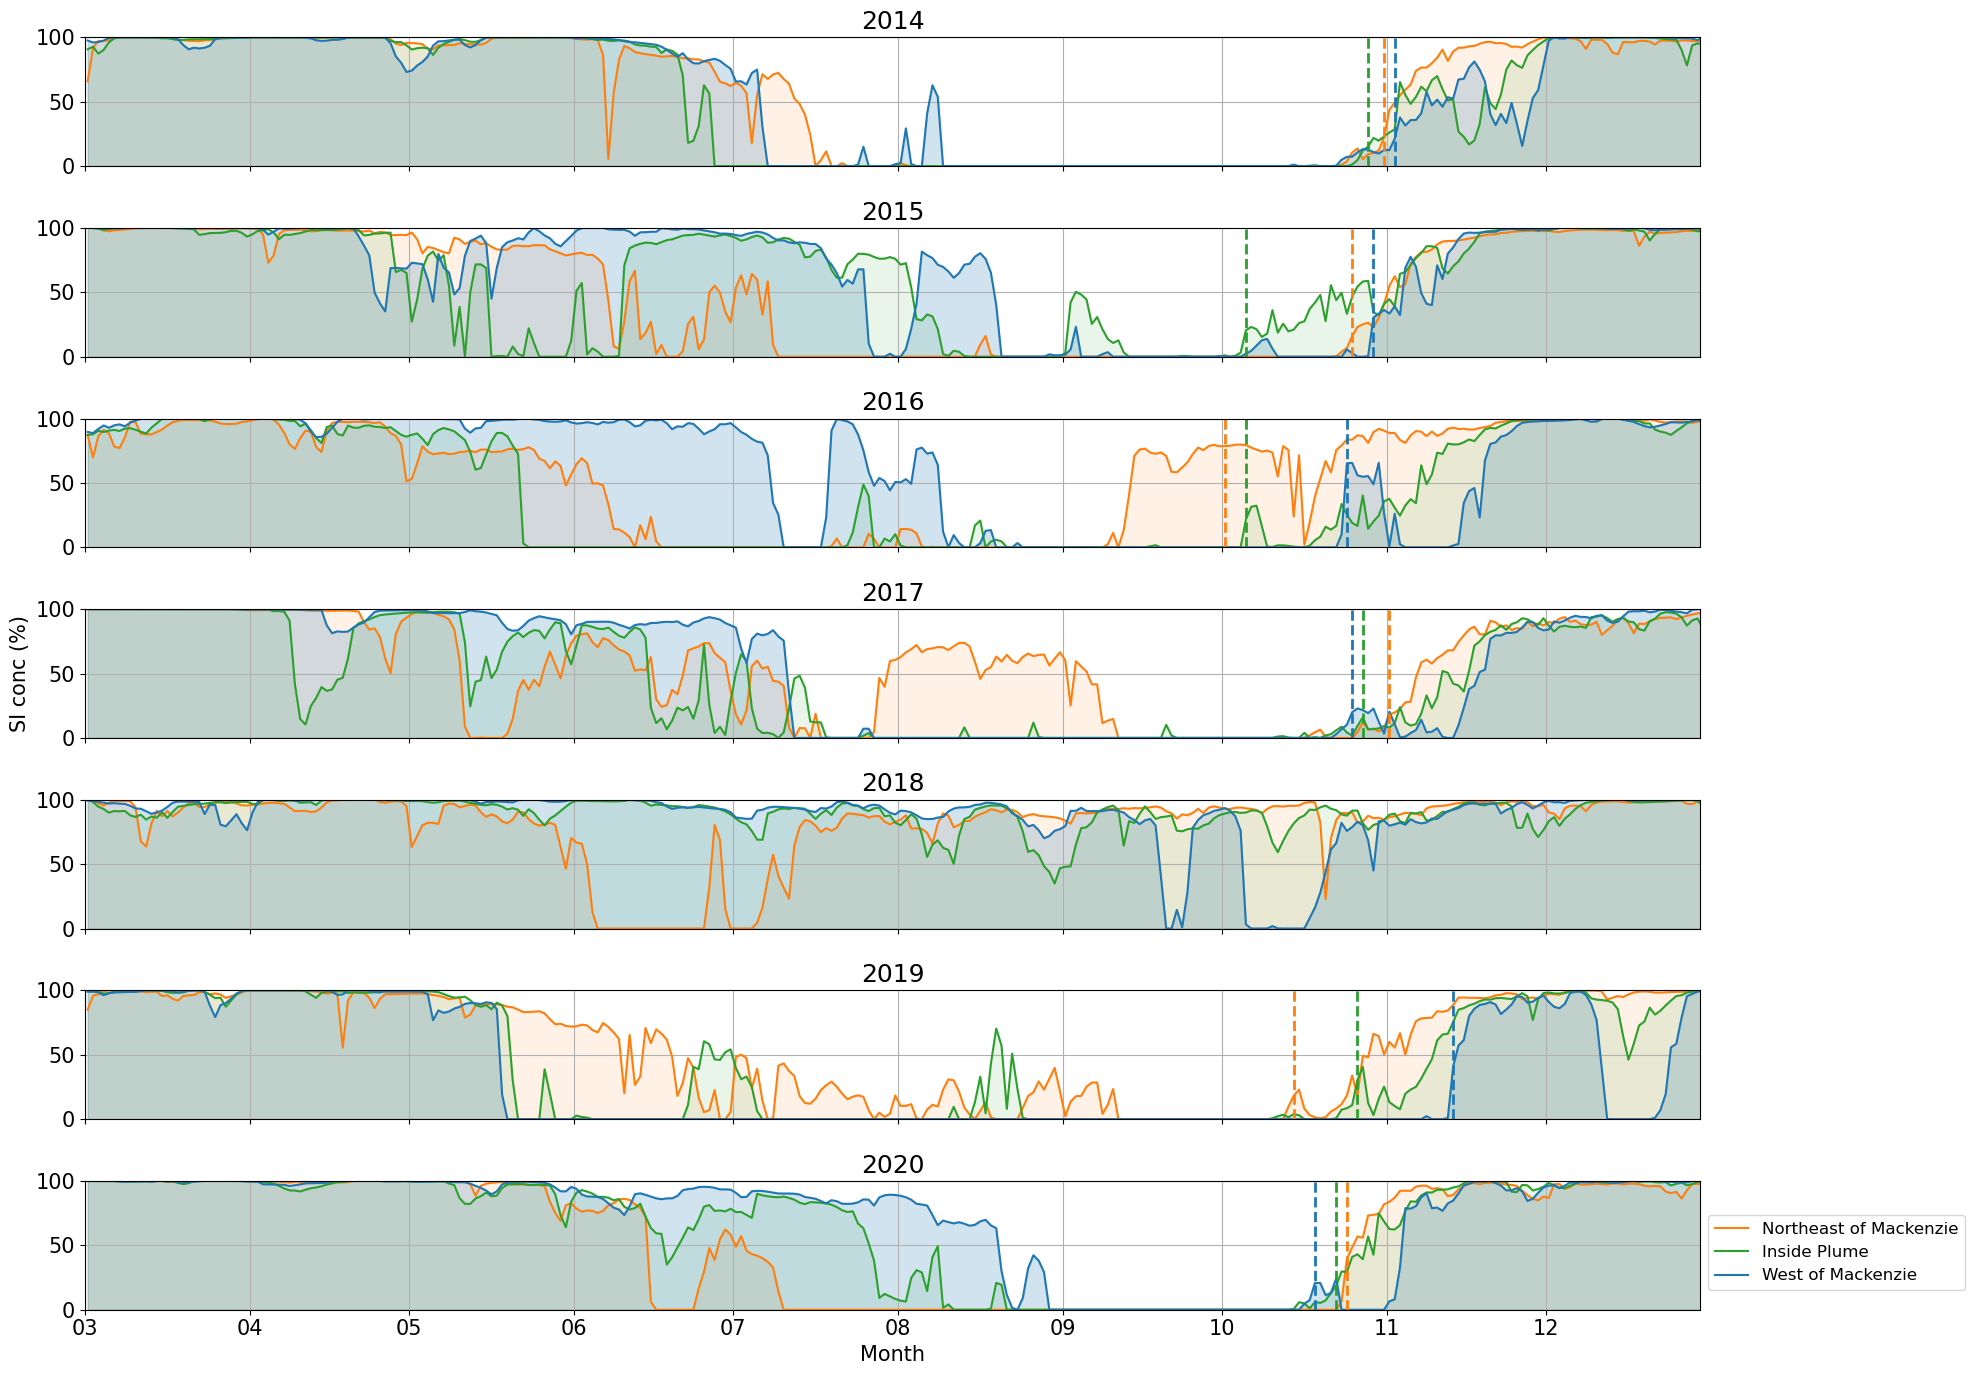

In [15]:
plt.rcParams['font.size'] = 15

years = np.arange(2014, 2021)  # 2014 to 2020 (including 2018)

fig, axes = plt.subplots(nrows=len(years), figsize=(20, 14))

for i, year in enumerate(years):
    ax = axes[i]
    
    # Select data for the given year
    start_date = f"{year}-03-01"
    end_date = f"{year}-12-30"

    ice_grid_west_timeseries = ice_day.isel(i=i_west, j=j_west).sel(time=slice(start_date, end_date)).chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")
    ice_grid_plume_timeseries = ice_day.isel(i=i_plume, j=j_plume).sel(time=slice(start_date, end_date)).chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")
    ice_grid_east_timeseries = ice_day.isel(i=i_east, j=j_east).sel(time=slice(start_date, end_date)).chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")

    # Plot each region's time series with shading
    ax.plot(ice_grid_east_timeseries.time, ice_grid_east_timeseries, label="Northeast of Mackenzie", color='tab:orange')
    ax.fill_between(ice_grid_east_timeseries.time, ice_grid_east_timeseries, 0, alpha=0.1, color='tab:orange')

    ax.plot(ice_grid_plume_timeseries.time, ice_grid_plume_timeseries, label="Inside Plume", color='tab:green')
    ax.fill_between(ice_grid_plume_timeseries.time, ice_grid_plume_timeseries, 0, alpha=0.1, color='tab:green')

    ax.plot(ice_grid_west_timeseries.time, ice_grid_west_timeseries, label="West of Mackenzie", color='tab:blue')
    ax.fill_between(ice_grid_west_timeseries.time, ice_grid_west_timeseries, 0, alpha=0.2, color='tab:blue')

    # Find first date when SIC ≥ 15% after October 1 (but skip 2018)
    if year != 2018:
        def find_sic_threshold(time_series):
            after_oct1 = time_series.sel(time=slice(f"{year}-10-01", end_date))
            threshold_dates = after_oct1.time.where(after_oct1.compute() >= 50, drop=True)
            return threshold_dates.values[0] if threshold_dates.size > 0 else None  # Get first occurrence

        dates_west = find_sic_threshold(ice_grid_west_timeseries)
        dates_plume = find_sic_threshold(ice_grid_plume_timeseries)
        dates_east = find_sic_threshold(ice_grid_east_timeseries)

        # Plot vertical lines if valid dates are found
        if dates_west:
            ax.axvline(dates_west, linestyle="dashed", linewidth=2, color='tab:blue')
        if dates_plume:
            ax.axvline(dates_plume, linestyle="dashed", linewidth=2, color='tab:green')
        if dates_east:
            ax.axvline(dates_east, linestyle="dashed", linewidth=2, color='tab:orange')

    ax.grid()
    ax.set_ylim(0, 100)
    ax.set_xlim([np.datetime64(start_date), np.datetime64(end_date)])

    # Remove tick labels except for the last (bottom) subplot
    if i < len(years) - 1:
        ax.set_xticklabels([])  # Hide tick labels for all but last subplot

    ax.set_ylabel("SI conc (%)" if i == len(years) // 2 else "")  # Only middle subplot gets a label

    # Title for each subplot
    ax.set_title(f"{year}")

# Format the x-axis of the last subplot
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks at the start of each month
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m"))  # Label ticks with month number (1-12)

# Add legend only to the last subplot
axes[-1].legend(loc='upper left', fontsize=12, bbox_to_anchor=[1, 0.8])

plt.xlabel("Month")
plt.tight_layout()
plt.show()

### Select box in plume

In [52]:
def identify_ice_date(sic_da, threshold=15):
    years = np.unique(ice_grid_plume['time'].dt.year)
    ice_dates = []
    for year in years:
        ice_yr = ice_grid_plume.sel(time=slice(f"{year}-10-01", f"{year}-12-31"))
        mask = ice_yr>15
        ice_yr_mask = ice_yr.isel(time=mask.compute())
        ice_dates.append(ice_yr_mask.time.values[0])
    return ice_dates

In [53]:
# identify when SIC>15 in the plume each year
ice_dates_plume = identify_ice_date(ice_grid_plume, threshold=15)

In [54]:
ice_dates_plume

[numpy.datetime64('2014-10-28T12:00:00.000000000'),
 numpy.datetime64('2015-10-05T12:00:00.000000000'),
 numpy.datetime64('2016-10-05T12:00:00.000000000'),
 numpy.datetime64('2017-10-27T12:00:00.000000000'),
 numpy.datetime64('2018-10-01T12:00:00.000000000'),
 numpy.datetime64('2019-10-26T12:00:00.000000000'),
 numpy.datetime64('2020-10-22T12:00:00.000000000')]

In [85]:
# select just beaufort region and ice date for each year
sigma0_beaufort = sigma0.sel(time=ice_dates_plume).isel(i=slice(450,750),j=slice(70,390))
SSS_beaufort = SA.sel(time=ice_dates_plume).isel(k=0,i=slice(450,750),j=slice(70,390))
SST_beaufort = CT.sel(time=ice_dates_plume).isel(k=0,i=slice(450,750),j=slice(70,390))
SIC_beaufort = ice_day.sel(time=ice_dates_plume).isel(i=slice(450,750),j=slice(70,390))

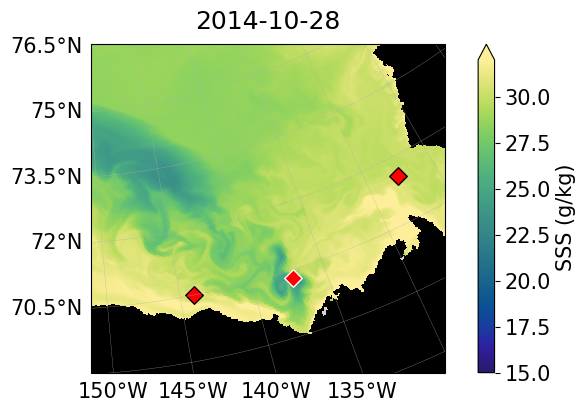

In [87]:
fig = plt.figure(figsize=(8,4), constrained_layout=True)
ax1 = fig.add_subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude = -155))
ax1.set_extent([-150, -128, 69, 75], ccrs.PlateCarree())

HH_grid_land.plot(x='XC',y='YC',ax=ax1,vmin=0,vmax=1,cmap='grey',transform=ccrs.PlateCarree(),add_colorbar=False)
cbar_mld = SSS_beaufort.isel(time=0).plot(x='XC',y='YC',ax=ax1,vmin=15,vmax=32,cmap=cmocean.cm.haline,transform=ccrs.PlateCarree(),cbar_kwargs={'label': 'SSS (g/kg)'});

ax1.set_facecolor('lightgray')
gl = ax1.gridlines(crs=ccrs.PlateCarree(), linewidth=0.2,draw_labels=True,x_inline=False, y_inline=False,\
                  xpadding=6,ypadding=6,rotate_labels=False)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = True

# add points for selected profiles with black outlines
ax1.scatter(HH_grid.isel(i=565,j=180).XC.values, HH_grid.isel(i=565,j=180).YC.values,
            c='r', edgecolors='white', marker='D', s=80, transform=ccrs.PlateCarree());

ax1.scatter(HH_grid.isel(i=540,j=250).XC.values, HH_grid.isel(i=540,j=250).YC.values,
            c='r', edgecolors='k', marker='D', s=80, transform=ccrs.PlateCarree());

ax1.scatter(HH_grid.isel(i=660,j=120).XC.values, HH_grid.isel(i=660,j=120).YC.values,
            c='r', edgecolors='k', marker='D', s=80, transform=ccrs.PlateCarree());

ax1.set_title(str(SSS_beaufort.isel(time=0).time.values)[0:10]);

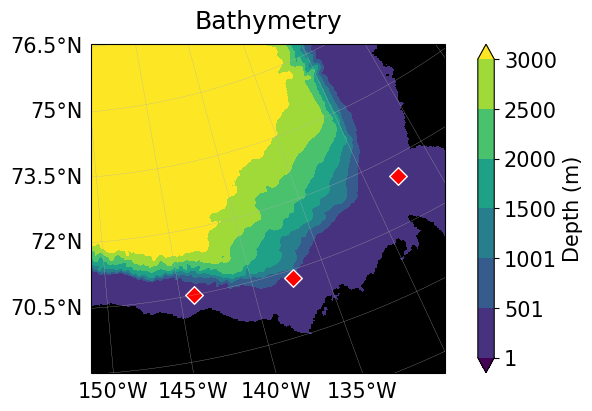

In [120]:
fig = plt.figure(figsize=(8,4), constrained_layout=True)
ax1 = fig.add_subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude = -155))
ax1.set_extent([-150, -128, 69, 75], ccrs.PlateCarree())

cbar_mld = HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth.plot.contourf(x='XC',y='YC',ax=ax1,vmin=1,vmax=3000,cmap='viridis',transform=ccrs.PlateCarree(),cbar_kwargs={'label': 'Depth (m)'});
HH_grid_land.plot(x='XC',y='YC',ax=ax1,vmin=0,vmax=1,cmap='grey',transform=ccrs.PlateCarree(),add_colorbar=False)

ax1.set_facecolor('lightgray')
gl = ax1.gridlines(crs=ccrs.PlateCarree(), linewidth=0.2,draw_labels=True,x_inline=False, y_inline=False,\
                  xpadding=6,ypadding=6,rotate_labels=False)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = True

# add points for selected profiles with black outlines
ax1.scatter(HH_grid.isel(i=565,j=180).XC.values, HH_grid.isel(i=565,j=180).YC.values,
            c='r', edgecolors='white', marker='D', s=80, transform=ccrs.PlateCarree());

ax1.scatter(HH_grid.isel(i=540,j=250).XC.values, HH_grid.isel(i=540,j=250).YC.values,
            c='r', edgecolors='white', marker='D', s=80, transform=ccrs.PlateCarree());

ax1.scatter(HH_grid.isel(i=660,j=120).XC.values, HH_grid.isel(i=660,j=120).YC.values,
            c='r', edgecolors='white', marker='D', s=80, transform=ccrs.PlateCarree());

ax1.set_title("Bathymetry");

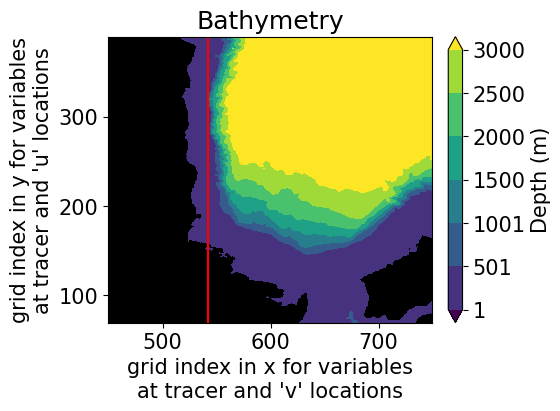

In [139]:
fig = plt.figure(figsize=(5.5,4), constrained_layout=True)
ax1 = fig.add_subplot(1,1,1)

cbar_mld = HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth.plot.contourf(ax=ax1,vmin=1,vmax=3000,cmap='viridis',cbar_kwargs={'label': 'Depth (m)'});
HH_grid_land.isel(i=slice(450,750),j=slice(70,390)).plot(ax=ax1,vmin=0,vmax=1,cmap='grey',add_colorbar=False)

ax1.set_facecolor('lightgray')

# # add points for selected profiles with black outlines
# ax1.scatter(HH_grid.isel(i=565,j=180).XC.values, HH_grid.isel(i=565,j=180).YC.values,
#             c='r', edgecolors='white', marker='D', s=80);

# ax1.scatter(HH_grid.isel(i=540,j=250).XC.values, HH_grid.isel(i=540,j=250).YC.values,
#             c='r', edgecolors='white', marker='D', s=80);

# ax1.scatter(HH_grid.isel(i=660,j=120).XC.values, HH_grid.isel(i=660,j=120).YC.values,
#             c='r', edgecolors='white', marker='D', s=80);

ax1.axvline(x=542,c='red')

ax1.set_title("Bathymetry");

### Plot map of MLD, SSS, SST, and SIC

In [11]:
MLD_all_time = []  # List to store MLD for each timestep

for t in range(len(sigma0_beaufort.time)):
    # Create a mask for locations where k=0 is NaN
    surface_nan_mask = sigma0_beaufort.isel(k=0, time=t).isnull()

    # Replace NaNs in the dataset with zero for calculations
    sigma0_filled = sigma0_beaufort.fillna(0)

    # Compute surface density
    rho_Z0 = sigma0_filled.isel(k=0, time=t)

    # Compute threshold density
    density_threshold = 0.03
    threshold = (rho_Z0 + density_threshold).values

    # Compute absolute difference from threshold
    density_minus_threshold = abs(sigma0_filled.isel(time=t) - threshold)

    # Find the index of the minimum difference, skipping NaNs
    threshold_idx = density_minus_threshold.argmin(dim='k', skipna=True)

    # Extract the corresponding depth value for MLD
    MLD = sigma0_beaufort.isel(k=threshold_idx.compute(), time=t).Z

    # Mask out grid cells where k=0 was originally NaN
    MLD = MLD.where(~surface_nan_mask, float('nan'))

    # Store in the list
    MLD_all_time.append(MLD)

# Combine the results into a single xarray DataArray
MLD_all_time = xr.concat(MLD_all_time, dim='time')
MLD_all_time = MLD_all_time.assign_coords(time=sigma0_beaufort.time)

NameError: name 'sigma0_beaufort' is not defined

In [ ]:
# Set up the figure and subplots (4 rows, 7 columns) with Cartopy
fig, axes = plt.subplots(4, 7, figsize=(17, 10), subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)}, layout='constrained')

# Define the colormap and range for each dataset
vmin_SSS = 15
vmax_SSS = 32
vmin_SST = -2
vmax_SST = 6
vmin_MLD = -20
vmax_MLD = 0
vmin_SIC = 0
vmax_SIC = 100

# Loop through each year and plot all variables
for year in range(0, 7):
    
    # SSS (Row 1)
    ax = axes[0, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SSS_beaufort.isel(time=year).plot(x='XC', y='YC', ax=ax, cmap=cmocean.cm.haline, vmin=vmin_SSS, vmax=vmax_SSS, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys', add_colorbar=False, transform=ccrs.PlateCarree())
    # ax.set_title(str(SSS_beaufort.isel(time=year).time.dt.year.values))
    ax.set_title(str(SSS_beaufort.isel(time=year).time.values)[0:10],fontsize=12)
    
    # SST (Row 2)
    ax = axes[1, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SST_beaufort.isel(time=year).plot(x='XC', y='YC', ax=ax, cmap='RdBu_r', vmin=vmin_SST, vmax=vmax_SST, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys', add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title("")

    # MLD (Row 3)
    ax = axes[2, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    MLD_all_time.isel(time=year).plot(x='XC', y='YC', ax=ax, cmap='turbo', vmin=vmin_MLD, vmax=vmax_MLD, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys', add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title("")
    
    # SIC (Row 4)
    ax = axes[3, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SIC_beaufort.where(SIC_beaufort>15).isel(time=year).plot(x='XC', y='YC', ax=ax, cmap=cmocean.cm.ice, vmin=vmin_SIC, vmax=vmax_SIC, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys', add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title("")
    
# Add colorbars to the last column
colorbars = [
    (cmocean.cm.haline, vmin_SSS, vmax_SSS, 'SSS (g/kg)'),
    ('RdBu_r', vmin_SST, vmax_SST, 'SST (°C)'),
    ('turbo', vmin_MLD, vmax_MLD, 'MLD (m)'),
    (cmocean.cm.ice, vmin_SIC, vmax_SIC, 'SIC (%)')
]

for i, (cmap, vmin, vmax, label) in enumerate(colorbars):
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=axes[i, -1], location='right')
    cbar.ax.set_ylabel(label)

# Set the main title
plt.suptitle('SSS, SST, MLD, and SIC when SIC>15% in Mackenzie Plume for each year', fontsize=15, y=1.05);

### Manual dates

In [102]:
ice_dates_plume = np.array(['2014-10-29T12',
                            '2015-10-11T12',
                            '2016-10-22T12',
                            '2017-10-26T12',
                            '2018-10-13T12',
                            '2019-10-26T12',
                            '2020-10-18T12'], dtype='datetime64[ns]')

In [103]:
ice_dates_plume

array(['2014-10-29T12:00:00.000000000', '2015-10-11T12:00:00.000000000',
       '2016-10-22T12:00:00.000000000', '2017-10-26T12:00:00.000000000',
       '2018-10-13T12:00:00.000000000', '2019-10-26T12:00:00.000000000',
       '2020-10-18T12:00:00.000000000'], dtype='datetime64[ns]')

In [104]:
# select just beaufort region and ice date for each year
sigma0_beaufort = sigma0.sel(time=ice_dates_plume).isel(i=slice(450,750),j=slice(70,390))
SSS_beaufort = SA.sel(time=ice_dates_plume).isel(k=0,i=slice(450,750),j=slice(70,390))
SST_beaufort = CT.sel(time=ice_dates_plume).isel(k=0,i=slice(450,750),j=slice(70,390))
SIC_beaufort = ice_day.sel(time=ice_dates_plume).isel(i=slice(450,750),j=slice(70,390))

### Plot map of MLD, SSS, SST, and SIC

In [105]:
MLD_all_time = []  # List to store MLD for each timestep

for t in range(len(sigma0_beaufort.time)):
    # Create a mask for locations where k=0 is NaN
    surface_nan_mask = sigma0_beaufort.isel(k=0, time=t).isnull()

    # Replace NaNs in the dataset with zero for calculations
    sigma0_filled = sigma0_beaufort.fillna(0)

    # Compute surface density
    rho_Z0 = sigma0_filled.isel(k=0, time=t)

    # Compute threshold density
    density_threshold = 0.03
    threshold = (rho_Z0 + density_threshold).values

    # Compute absolute difference from threshold
    density_minus_threshold = abs(sigma0_filled.isel(time=t) - threshold)

    # Find the index of the minimum difference, skipping NaNs
    threshold_idx = density_minus_threshold.argmin(dim='k', skipna=True)

    # Extract the corresponding depth value for MLD
    MLD = sigma0_beaufort.isel(k=threshold_idx.compute(), time=t).Z

    # Mask out grid cells where k=0 was originally NaN
    MLD = MLD.where(~surface_nan_mask, float('nan'))

    # Store in the list
    MLD_all_time.append(MLD)

# Combine the results into a single xarray DataArray
MLD_all_time = xr.concat(MLD_all_time, dim='time')
MLD_all_time = MLD_all_time.assign_coords(time=sigma0_beaufort.time)

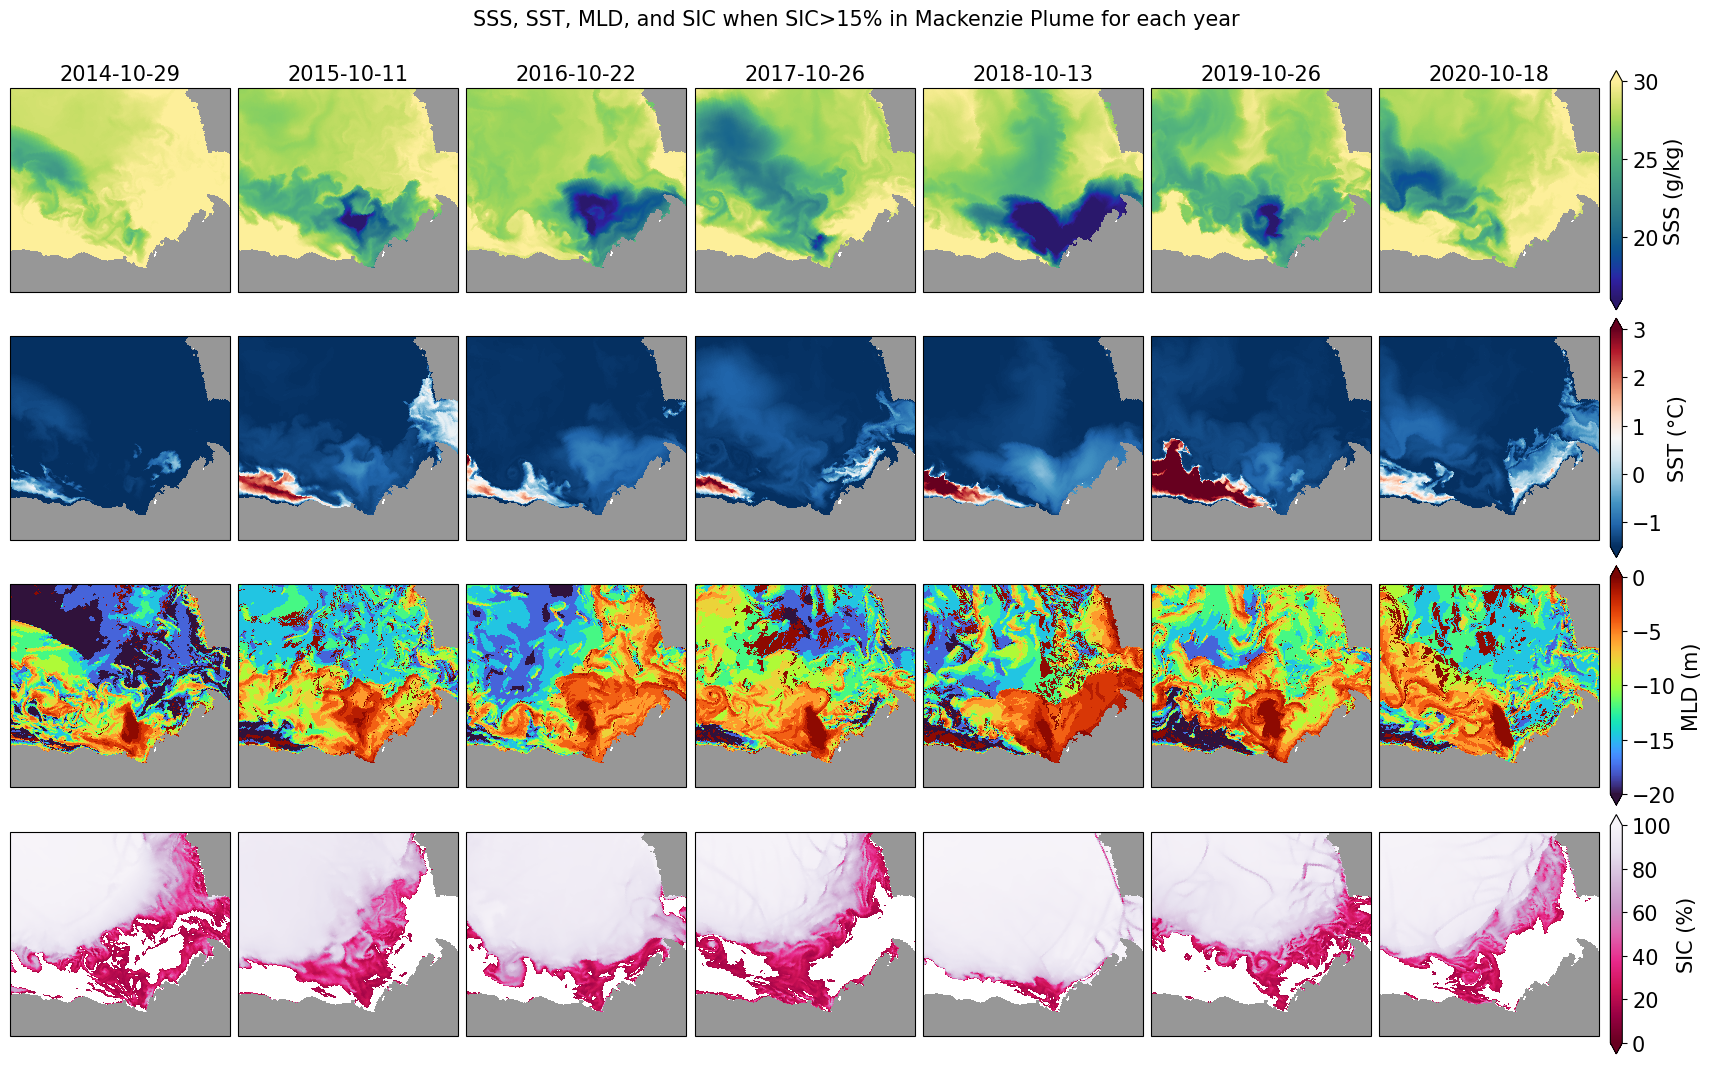

In [112]:
# Set up the figure and subplots (4 rows, 7 columns) with Cartopy
fig, axes = plt.subplots(4, 7, figsize=(17, 10), subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)}, layout='constrained')

# Define the colormap and range for each dataset
vmin_SSS = 16
vmax_SSS = 30
vmin_SST = -1.5
vmax_SST = 3
vmin_MLD = -20
vmax_MLD = 0
vmin_SIC = 0
vmax_SIC = 100

# Loop through each year and plot all variables
for year in range(0, 7):
    
    # SSS (Row 1)
    ax = axes[0, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SSS_beaufort.isel(time=year).plot(x='XC', y='YC', ax=ax, cmap=cmocean.cm.haline, vmin=vmin_SSS, vmax=vmax_SSS, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    # ax.set_title(str(SSS_beaufort.isel(time=year).time.dt.year.values))
    ax.set_title(str(SSS_beaufort.isel(time=year).time.values)[0:10],fontsize=15)
    
    # SST (Row 2)
    ax = axes[1, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SST_beaufort.isel(time=year).plot(x='XC', y='YC', ax=ax, cmap='RdBu_r', vmin=vmin_SST, vmax=vmax_SST, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title("")

    # MLD (Row 3)
    ax = axes[2, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    MLD_all_time.isel(time=year).plot(x='XC', y='YC', ax=ax, cmap='turbo', vmin=vmin_MLD, vmax=vmax_MLD, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title("")
    
    # SIC (Row 4)
    ax = axes[3, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SIC_beaufort.where(SIC_beaufort>15).isel(time=year).plot(x='XC', y='YC', ax=ax, cmap='PuRd_r', vmin=vmin_SIC, vmax=vmax_SIC, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title("")
    
# Add colorbars to the last column
colorbars = [
    (cmocean.cm.haline, vmin_SSS, vmax_SSS, 'SSS (g/kg)'),
    ('RdBu_r', vmin_SST, vmax_SST, 'SST (°C)'),
    ('turbo', vmin_MLD, vmax_MLD, 'MLD (m)'),
    ('PuRd_r', vmin_SIC, vmax_SIC, 'SIC (%)')
]

for i, (cmap, vmin, vmax, label) in enumerate(colorbars):
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=axes[i, -1], location='right',extend='both')
    cbar.ax.set_ylabel(label)

# Set the main title
plt.suptitle('SSS, SST, MLD, and SIC when SIC>15% in Mackenzie Plume for each year', fontsize=15, y=1.05);

### Add bathymetry

In [127]:
bathy_beaufort = HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth

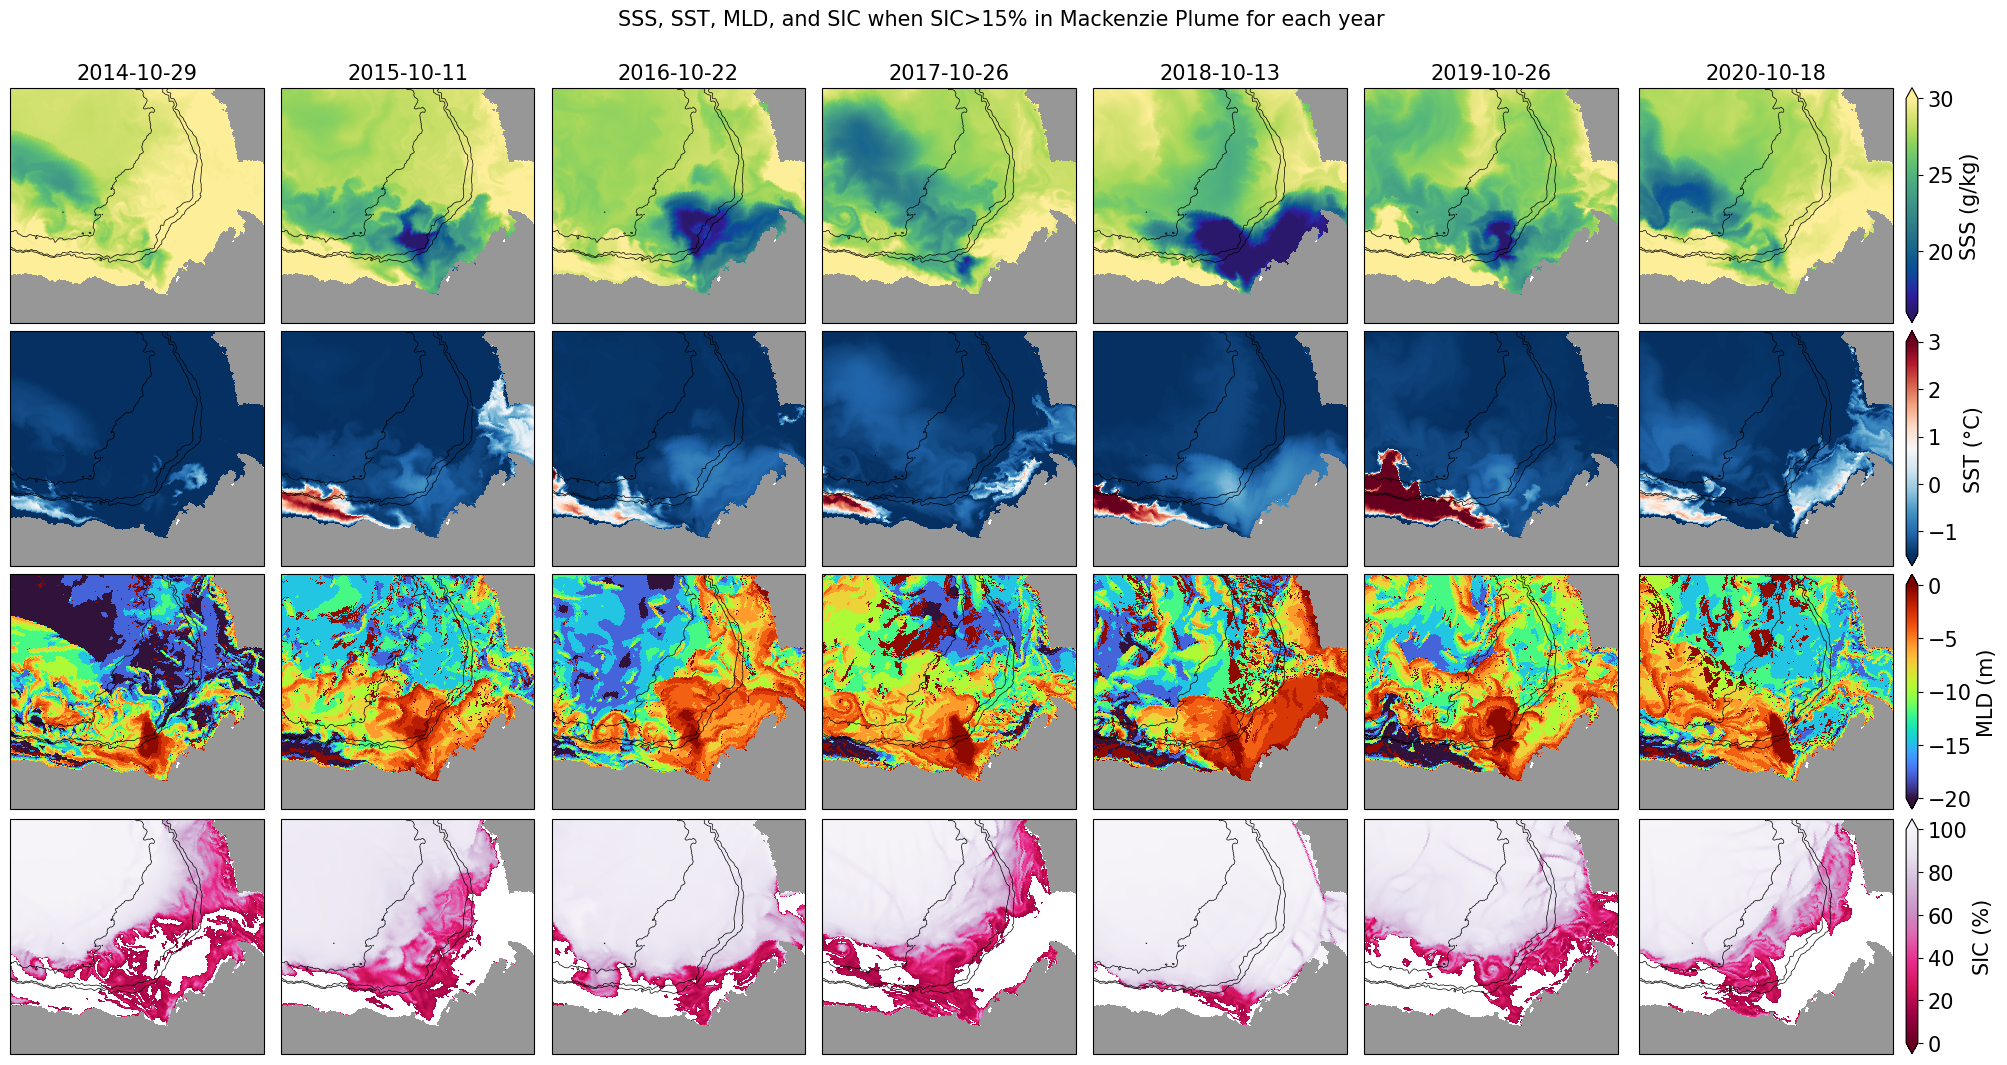

In [137]:
# Set up the figure and subplots (4 rows, 7 columns) with Cartopy
fig, axes = plt.subplots(4, 7, figsize=(20, 10), subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)}, layout='constrained')

# Define the colormap and range for each dataset
vmin_SSS = 16
vmax_SSS = 30
vmin_SST = -1.5
vmax_SST = 3
vmin_MLD = -20
vmax_MLD = 0
vmin_SIC = 0
vmax_SIC = 100

# Loop through each year and plot all variables
for year in range(0, 7):
    
    # SSS (Row 1)
    ax = axes[0, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SSS_beaufort.isel(time=year).plot(x='XC', y='YC', ax=ax, cmap=cmocean.cm.haline, vmin=vmin_SSS, vmax=vmax_SSS, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    bathy_beaufort.plot.contour(x='XC', y='YC', ax=ax, colors='k', linewidths=0.5, levels=[500,1000,3000], transform=ccrs.PlateCarree())
    # ax.set_title(str(SSS_beaufort.isel(time=year).time.dt.year.values))
    ax.set_title(str(SSS_beaufort.isel(time=year).time.values)[0:10],fontsize=15)
    
    # SST (Row 2)
    ax = axes[1, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SST_beaufort.isel(time=year).plot(x='XC', y='YC', ax=ax, cmap='RdBu_r', vmin=vmin_SST, vmax=vmax_SST, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    bathy_beaufort.plot.contour(x='XC', y='YC', ax=ax, colors='k', linewidths=0.5, levels=[500,1000,3000], transform=ccrs.PlateCarree())
    ax.set_title("")

    # MLD (Row 3)
    ax = axes[2, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    MLD_all_time.isel(time=year).plot(x='XC', y='YC', ax=ax, cmap='turbo', vmin=vmin_MLD, vmax=vmax_MLD, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    bathy_beaufort.plot.contour(x='XC', y='YC', ax=ax, colors='k', linewidths=0.5, levels=[500,1000,3000], transform=ccrs.PlateCarree())
    ax.set_title("")
    
    # SIC (Row 4)
    ax = axes[3, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SIC_beaufort.where(SIC_beaufort>15).isel(time=year).plot(x='XC', y='YC', ax=ax, cmap='PuRd_r', vmin=vmin_SIC, vmax=vmax_SIC, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    bathy_beaufort.plot.contour(x='XC', y='YC', ax=ax, colors='k', linewidths=0.5, levels=[500,1000,3000], transform=ccrs.PlateCarree())
    ax.set_title("")
    
# Add colorbars to the last column
colorbars = [
    (cmocean.cm.haline, vmin_SSS, vmax_SSS, 'SSS (g/kg)'),
    ('RdBu_r', vmin_SST, vmax_SST, 'SST (°C)'),
    ('turbo', vmin_MLD, vmax_MLD, 'MLD (m)'),
    ('PuRd_r', vmin_SIC, vmax_SIC, 'SIC (%)')
]

for i, (cmap, vmin, vmax, label) in enumerate(colorbars):
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=axes[i, -1], location='right',extend='both')
    cbar.ax.set_ylabel(label)

# Set the main title
plt.suptitle('SSS, SST, MLD, and SIC when SIC>15% in Mackenzie Plume for each year', fontsize=15, y=1.05);

### Plot time series of sea ice along i=542

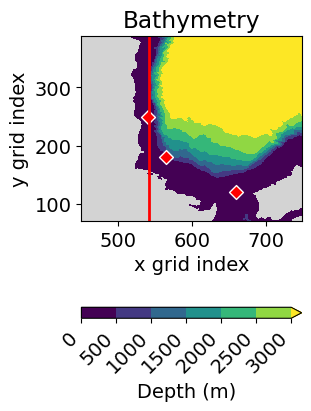

In [41]:
plt.rcParams['font.size'] = 14

fig = plt.figure(figsize=(3,4), constrained_layout=True)
ax1 = fig.add_subplot(1,1,1)

# Plot bathymetry with a horizontal colorbar
cbar_mld = HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth.where(HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth>0).plot.contourf(
    ax=ax1, vmin=0, vmax=3000, cmap='viridis',
    cbar_kwargs={'label': 'Depth (m)', 'orientation': 'horizontal', 'pad': 0.15}
)

# HH_grid_land.isel(i=slice(450,750), j=slice(70,390)).plot(ax=ax1, cmap='grey', add_colorbar=False)

ax1.set_facecolor('lightgray')

# Add points for selected profiles with black outlines
ax1.scatter(x=565, y=180, c='r', edgecolors='white', marker='D', s=50)
ax1.scatter(x=540, y=250, c='r', edgecolors='white', marker='D', s=50)
ax1.scatter(x=660, y=120, c='r', edgecolors='white', marker='D', s=50)

ax1.axvline(x=542, c='red', linewidth=2)
ax1.set_ylabel("y grid index")
ax1.set_xlabel("x grid index")
ax1.set_title("Bathymetry")

# Rotate colorbar tick labels
cbar = cbar_mld.colorbar
plt.setp(cbar.ax.get_xticklabels(), rotation=45, ha="right")  # Adjust rotation and alignment

plt.show()

In [46]:
depth_flip = xr.DataArray(np.rot90(HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth.where(HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth>0),3), dims=['i','j'])

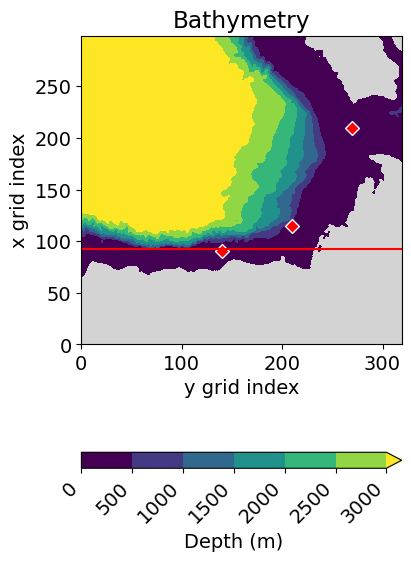

In [56]:
plt.rcParams['font.size'] = 14

fig = plt.figure(figsize=(4,5.5), constrained_layout=True)
ax1 = fig.add_subplot(1,1,1)

# Plot bathymetry with a horizontal colorbar
cbar_mld = depth_flip.plot.contourf(
    ax=ax1, vmin=0, vmax=3000, cmap='viridis',
    cbar_kwargs={'label': 'Depth (m)', 'orientation': 'horizontal', 'pad': 0.15}
)

ax1.set_facecolor('lightgray')

# Add points for selected profiles with black outlines
ax1.scatter(y=565-450, x=390-180, c='r', edgecolors='white', marker='D', s=50)
ax1.scatter(y=540-450, x=390-250, c='r', edgecolors='white', marker='D', s=50)
ax1.scatter(y=660-450, x=390-120, c='r', edgecolors='white', marker='D', s=50)

ax1.axhline(y=542-450,c='red')

# ax1.axvline(x=542, c='red', linewidth=2)
ax1.set_ylabel("x grid index")
ax1.set_xlabel("y grid index")
ax1.set_title("Bathymetry")

# Rotate colorbar tick labels
cbar = cbar_mld.colorbar
plt.setp(cbar.ax.get_xticklabels(), rotation=45, ha="right")  # Adjust rotation and alignment

plt.show()

In [12]:
SIC_beaufort = ice_day.isel(i=542,j=slice(70,390)).chunk(dict(time=-1)).interpolate_na(dim="time", method="linear")

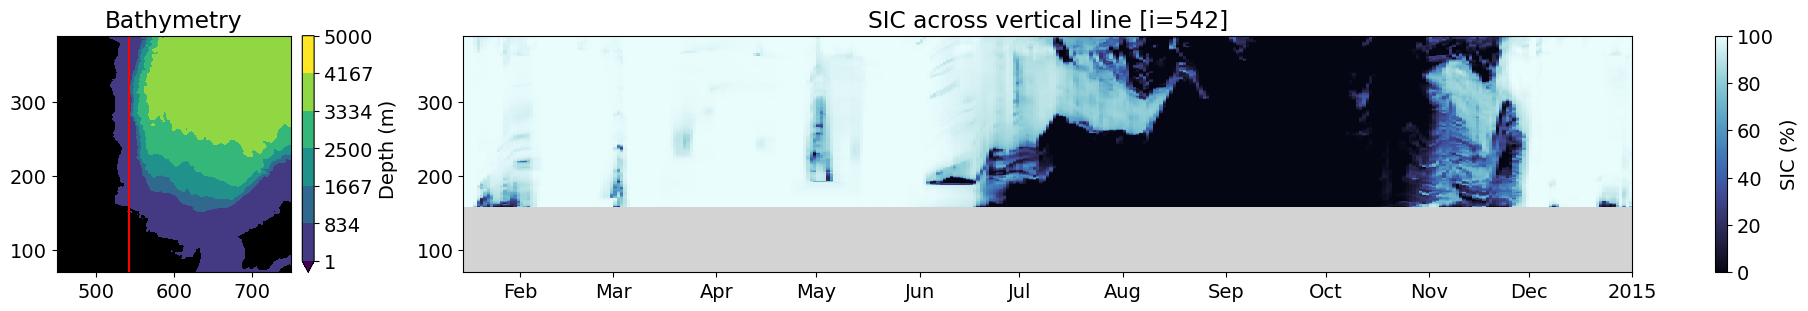

In [184]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(18, 3), gridspec_kw={'width_ratios': [1, 5]}, layout='constrained')

cbar_mld = HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth.plot.contourf(ax=ax1,vmin=1,vmax=5000,
                                                                              cmap='viridis',cbar_kwargs={'label': 'Depth (m)'});
HH_grid_land.isel(i=slice(450,750),j=slice(70,390)).plot(ax=ax1,vmin=0,vmax=1,cmap='gray',add_colorbar=False)
ax1.axvline(x=542,c='red')
ax1.set_title('Bathymetry')
ax1.set_ylabel("")
ax1.set_xlabel("")

SIC_beaufort.sel(time='2014').plot(ax=ax2,y='j',cmap=cmocean.cm.ice, cbar_kwargs={'label': 'SIC (%)'})
ax2.set_title('SIC across vertical line [i=542]')
ax2.set_facecolor('lightgray')
ax2.set_ylabel("")
ax2.set_xlabel("");

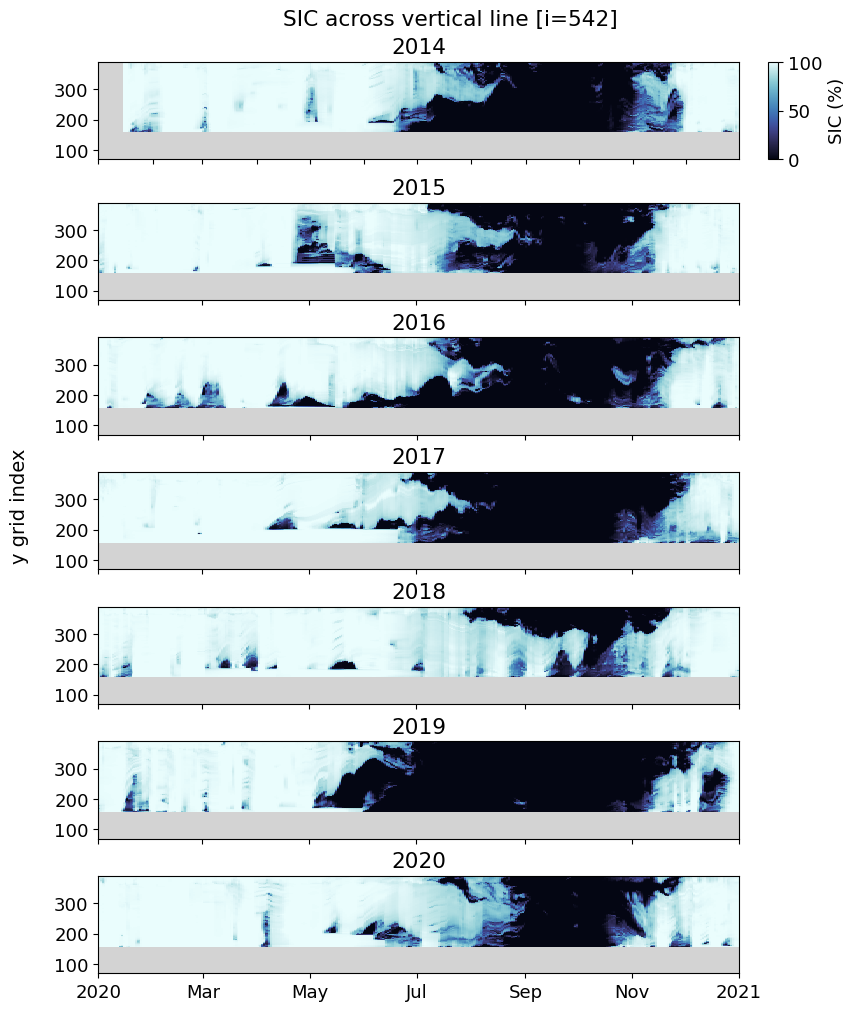

In [36]:
plt.rcParams['font.size'] = 13

# Define the number of rows and years
years = range(2014, 2021)  # 2014 to 2020 (7 years)

# Create a figure with 7 rows and 1 column
fig, axes = plt.subplots(7, 1, figsize=(8, 10), layout='constrained')

# Plot SIC for each year
for i, year in enumerate(years):
    ax = axes[i]
    # SIC_plot = SIC_beaufort.sel(time=str(year)).plot(ax=ax, y='j', cmap=cmocean.cm.ice, add_colorbar=(i == 0), 
    #                                                  cbar_kwargs={'label': 'SIC (%)'} if i == 0 else {})
    SIC_plot = SIC_beaufort.sel(time=str(year)).plot(ax=ax, y='j', cmap=cmocean.cm.ice, add_colorbar=(i == 0), 
                                                     cbar_kwargs={'label': 'SIC (%)', 'orientation': 'vertical', 'pad': 0.01, 'aspect': 10} if i == 0 else {})

    ax.set_title(year)
    ax.set_facecolor('lightgray')
    ax.set_ylabel("")
    ax.set_xlabel("")

    # Remove x-axis labels except for the last subplot
    if i != len(years) - 1:
        ax.set_xticklabels([])

# Set x-axis limits
axes[0].set_xlim(np.datetime64("2014-01-01"), np.datetime64("2014-12-31"))

# Add a general y-label on the side
fig.text(-0.05, 0.5, "y grid index", va='center', rotation='vertical', fontsize=14)

plt.suptitle("SIC across vertical line [i=542]")
plt.show()